In [27]:
from pathlib import Path
from typing import Any, Tuple, Callable

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

from numpy import dtype, float64
from scipy.spatial.distance import cdist
from mealpy import FloatVar, ABC, Problem

from minisom import MiniSom
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler

In [28]:
data = pd.read_csv("../data/processed/pca_data.csv")
data.head(20)

,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,04/06/2001,P1,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349
1,04/06/2001,P2,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170
2,04/06/2001,P3,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689
3,04/06/2001,P4,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264
4,04/07/2001,P1,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335
5,04/07/2001,P2,-2.132548,0.532214,-0.262256,0.078161,-0.227430,-0.337815,-0.472315,-0.422092,-0.392760,-0.015021
6,04/07/2001,P3,-2.117197,0.478984,-0.206697,0.078746,-0.231596,-0.325558,-0.468654,-0.420190,-0.383090,0.023730
7,04/07/2001,P4,-2.098488,0.522425,-0.254046,0.106607,-0.230658,-0.215664,-0.346504,-0.424520,-0.464356,0.012026
8,20/03/2002,P1,-2.358286,0.339262,-0.034405,0.217801,-0.236129,-0.071839,-0.443520,-0.288653,-0.345643,0.393474
9,20/03/2002,P2,-2.237500,0.425845,-0.233494,0.152536,-0.242958,-0.155881,-0.544733,-0.161736,-0.370111,0.375676


## Entrenamiento para clasificación con K-Means

Para realizar un entrenamiento no supervisado con una base de datos de parámetros químicos, la mejor opción es utilizar un Mapa Auto-Organizado (SOM) o un Autoencoder. Sin embargo, dado que ya se tiene los componentes principales (PCA), la técnica más robusta y estándar para encontrar grupos (clusters) es el K-Means Clustering potenciado por una Red Neuronal para validación.

### Preparación de los datos (Inputs del PCA)

Usaremos los componentes que explican la mayor parte de la varianza (según tu tabla, los primeros 5 o 6 son los más informativos).

In [29]:
# Método del codo

def elbow_method(x_data: pd.DataFrame) -> None:
    # Determinamos el número óptimo de clusters (Método del Codo)
    wcss = []
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        kmeans.fit(x_data)
        wcss.append([i, kmeans.inertia_])

    wcss_df = pd.DataFrame(wcss, columns=['n_cluster', 'wcss'])

    sns.lineplot(data=wcss_df, x='n_cluster', y='wcss', marker='o')

    # Determinacion de punto de cambio de pendiente (codo)
    wcss_df['dwcss'] = wcss_df['wcss'].diff()
    wcss_df['dn_cluster'] = wcss_df['n_cluster'].diff()
    wcss_df['slope'] = wcss_df['dwcss']/wcss_df['dn_cluster']

    wcss_df['d_slope'] = wcss_df['slope'].diff()

    elbow_index = wcss_df['d_slope'].idxmax()
    elbow_point = wcss_df.loc[elbow_index]

    print(wcss_df)

    sns.scatterplot(x=[elbow_point['n_cluster']], y=[elbow_point['wcss']], color='red', s=80, zorder=5)

    for x, y in zip(wcss_df["n_cluster"], wcss_df["wcss"]):
        plt.annotate(f'{x, int(y)}', (x, y), textcoords="offset points", xytext=(15,10), ha='center', fontsize=9)

    plt.title('Método del Codo para detectar Clusters')
    plt.xlabel('Número de clusters')
    plt.ylabel('WCSS (Inercia)')
    plt.grid(linestyle='--', alpha=0.5)
    plt.savefig('./graphs/training/codo_metodo_nclusters.png')
    plt.show()

   n_cluster         wcss        dwcss  dn_cluster        slope     d_slope
0          1  5847.309473          NaN         NaN          NaN         NaN
1          2  4464.967223 -1382.342249         1.0 -1382.342249         NaN
2          3  3675.993634  -788.973590         1.0  -788.973590  593.368659
3          4  2891.635167  -784.358467         1.0  -784.358467    4.615123
4          5  2584.789410  -306.845757         1.0  -306.845757  477.512709
5          6  2303.875891  -280.913519         1.0  -280.913519   25.932238
6          7  2131.798012  -172.077879         1.0  -172.077879  108.835640
7          8  1927.143829  -204.654183         1.0  -204.654183  -32.576304
8          9  1858.131640   -69.012189         1.0   -69.012189  135.641994
9         10  1581.686027  -276.445613         1.0  -276.445613 -207.433424


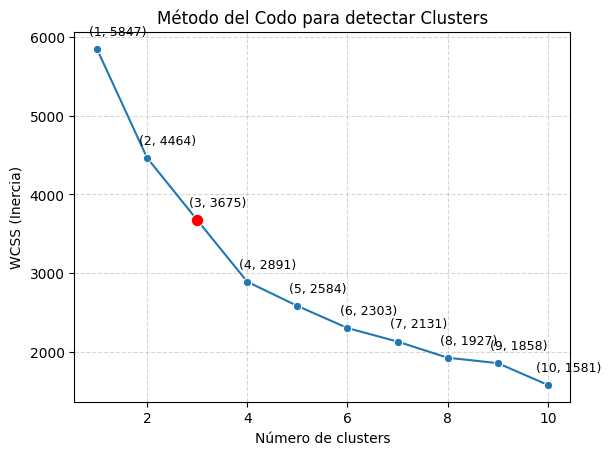

In [ ]:
# Usamos los resultados del PCA
# Seleccionamos, por ejemplo, los primeros 5 componentes principales
X_unsupervised = data.iloc[:, 2:7].copy() 

elbow_method(X_unsupervised)

In [31]:

def run_silhouette_score(data: pd.DataFrame, n_clusters: int, n_rows: int = 3, n_cols: int = 3) -> Tuple[np.ndarray[Any, dtype[float64]], int]:

    silhouette_data: np.ndarray[Any, dtype[float64]] = np.zeros([n_clusters, 2])

    i_row: int = 0
    i_col: int = 0

    fig, ax_1 = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 3*n_rows))

    for n_clusters_opt in range(2, n_clusters+2):
        # Crear el subplot
        ax_1[i_row, i_col].set_xlim([-0.1, 1])
        
        # Entrenar el modelo
        clusterer: KMeans = KMeans(n_clusters=n_clusters_opt, random_state=10)
        cluster_labels: np.ndarray[Any, Any] = clusterer.fit_predict(X_unsupervised)

        # Calcular el promedio de silueta (la línea punteada)
        silhouette_avg = silhouette_score(X_unsupervised, cluster_labels)
        print(f"Para n_clusters = {n_clusters_opt}, el promedio es: {silhouette_avg:.3f}")

        # Calcular el coeficiente de cada muestra
        sample_silhouette_values = silhouette_samples(X_unsupervised, cluster_labels)

        y_lower = 10
        for i in range(n_clusters_opt):
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters_opt)
            ax_1[i_row, i_col].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                            facecolor=color, edgecolor=color, alpha=0.7)

            y_lower = y_upper + 10 

        ax_1[i_row, i_col].axvline(x=silhouette_avg, color="red", linestyle="--")
        ax_1[i_row, i_col].set_title(f"Análisis de silueta para k = {n_clusters_opt}, cs={np.round(silhouette_avg,4)}")
        ax_1[i_row, i_col].set_xlabel('Coeficiente silueta')

        silhouette_data[n_clusters_opt-2, 0] = n_clusters_opt
        silhouette_data[n_clusters_opt-2, 1] = silhouette_avg

        # Actualizando contadores
        if i_col < n_cols-1:
            i_col += 1
        else:
            i_col = 0
            if i_row < n_rows-1:
                i_row += 1
            else:
                i_row = 0

    plt.tight_layout()
    plt.savefig(f'./graphs/training/graf_silueta.png')
    plt.show()

    silhouette_df = pd.DataFrame(silhouette_data, columns=['n_cluster', 'cs'])

    sns.lineplot(data=silhouette_df, x='n_cluster', y='cs', marker='o')
    sns.scatterplot(x=[4], y=[0.4034], color='red', s=80, zorder=5)

    for x, y in zip(silhouette_df["n_cluster"], silhouette_df["cs"]):
        plt.annotate(f'{x, np.round(y, 4)}', (x, y), textcoords="offset points", xytext=(15,10), ha='center', fontsize=9)

    plt.title('Análisis de coeficiente de silueta')
    plt.xlabel('n_clusters')
    plt.ylabel('Coef. silueta promedio')
    plt.grid(linestyle='--', alpha=0.5)
    # plt.ylim([0.35, 0.415])
    # plt.xlim([1, 11])
    plt.savefig(f'./graphs/training/coef_silueta_line.png')

    n_clusters_opt = int(silhouette_data[np.argmax(silhouette_data[:, 1]), 0])
    print(f'El n_cluster optimo {n_clusters_opt}')

    return silhouette_data, n_clusters_opt

Para n_clusters = 2, el promedio es: 0.394
Para n_clusters = 3, el promedio es: 0.401
Para n_clusters = 4, el promedio es: 0.403
Para n_clusters = 5, el promedio es: 0.365
Para n_clusters = 6, el promedio es: 0.382
Para n_clusters = 7, el promedio es: 0.384
Para n_clusters = 8, el promedio es: 0.388
Para n_clusters = 9, el promedio es: 0.392
Para n_clusters = 10, el promedio es: 0.356


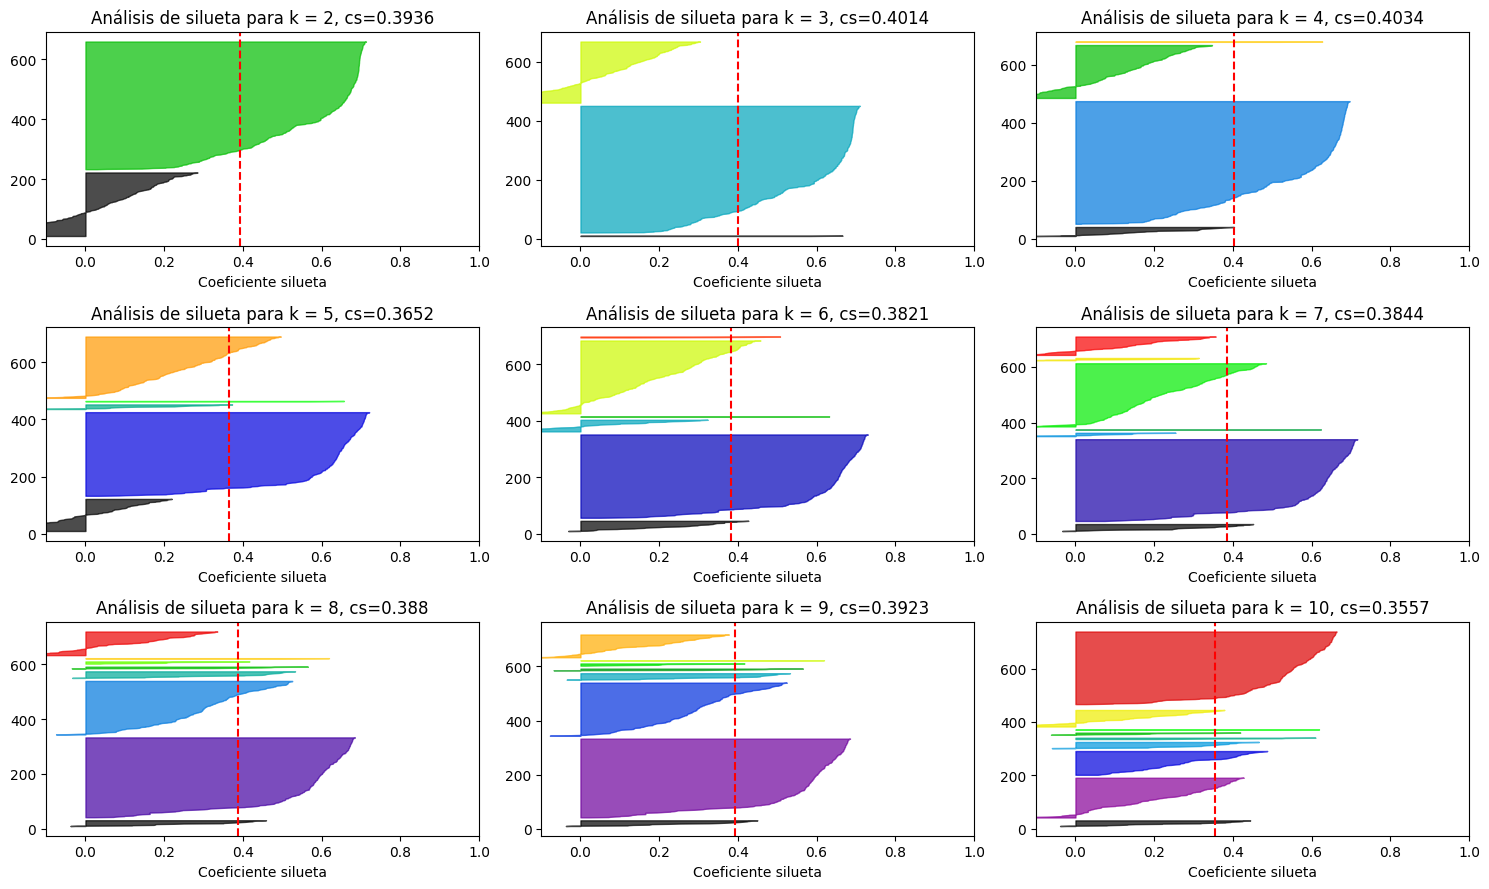

El n_cluster optimo 4


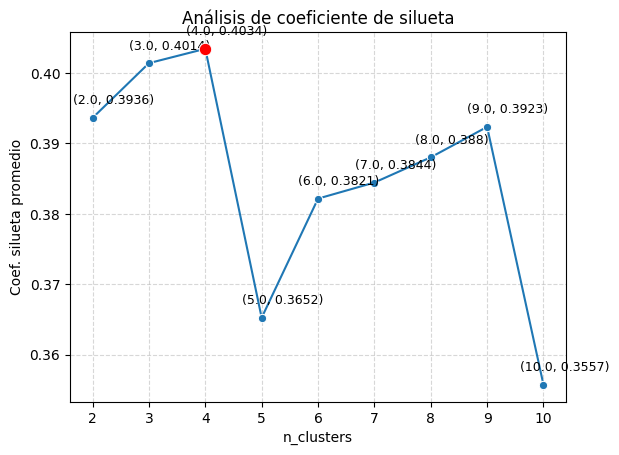

In [32]:
# metodo de coeficiente de silueta
n_range_clusters = 9
n_rows = 3
n_cols = 3

silhouette_data, n_clusters_opt = run_silhouette_score(data, n_range_clusters, n_rows, n_cols)

### Entrenamiento del Modelo de Clasificación

Una vez identificado el número de grupos (supongamos que el "codo" está en 3 o 4 clusters), ejecutamos el entrenamiento final.

In [ ]:
data_pc10 = data.drop(columns=['referencia', 'fecha'], axis=0)

# Entrenamos con el número de clusters elegido
model_knn = KMeans(n_clusters=n_clusters_opt, init='k-means++', random_state=42)
clusters_knn = model_knn.fit_predict(data_pc10)
centroides_knn = model_knn.cluster_centers_


### Gráfico de Dispersión 2D (Visualización Estándar)

Primero, asegúrate de tener en un solo lugar los componentes y las etiquetas de los clusters que generó el modelo.

In [34]:
data_train = data.copy()
data_train['cluster_knn'] = clusters_knn # Las etiquetas que generó el modelo K-Means
data_train.head()

,fecha,referencia,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_knn
0,04/06/2001,P1,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,0
1,04/06/2001,P2,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,0
2,04/06/2001,P3,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,0
3,04/06/2001,P4,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,0
4,04/07/2001,P1,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,0


Este gráfico te permitirá ver cómo el algoritmo separó las muestras de agua. Si los grupos están bien definidos, verás "nubes" de puntos de distintos colores.

In [35]:

def empty_directory(directory_path):
    path = Path(directory_path)
    if path.is_dir():
        return not any(path.iterdir())
    else:
        raise ValueError("This path is not a directory")

def graph_dist_clusters(data, column_names, pca_n_cols, pca_n_rows, column_analysed, output_path):

    # Verificando que el directorio para generar las graficas este vacios

    directory_path = Path(output_path).parent
    
    try:
        if empty_directory(directory_path):
            print("Directory is empty. ok")
            pca_i_row = 0
            pca_i_col = 0

            for pca_column_name_1 in column_names:

                fig_pca, ax_pca = plt.subplots(pca_n_rows, pca_n_cols, figsize=(5*pca_n_cols, 3*pca_n_rows))
                
                for pca_column_name_2 in column_names:
                    
                    sns.scatterplot(
                        data=data, 
                        x=pca_column_name_1,
                        y=pca_column_name_2,
                        hue=column_analysed,
                        palette='viridis',
                        s=15,
                        alpha=1,
                        edgecolor='w',
                        ax=ax_pca[pca_i_row, pca_i_col]
                    )

                    # Personalización de títulos (basado en tu interpretación de loadings
                    ax_pca[pca_i_row, pca_i_col].set_title(f'{pca_column_name_1} vs {pca_column_name_2}')
                    ax_pca[pca_i_row, pca_i_col].set_xlabel(f'{pca_column_name_1}')
                    ax_pca[pca_i_row, pca_i_col].set_ylabel(f'{pca_column_name_2}')
                    ax_pca[pca_i_row, pca_i_col].grid(True, linestyle='--', alpha=0.5)

                    # Actualizacón de contadores
                    if pca_i_row < pca_n_rows-1:
                        pca_i_row += 1
                    else:
                        pca_i_row = 0
                    
                    if pca_i_col < pca_n_cols-1:
                        pca_i_col += 1
                    else:
                        pca_i_col = 0
                
                plt.tight_layout()
                plt.savefig(output_path+f'{pca_column_name_1}.png')
                plt.show()
        else:
            print(f"This directory {directory_path} is not empty. Choose another one.")
    except ValueError as e:
        print(e)
    

In [36]:
column_names_knn = data_train.drop(columns=['fecha', 'referencia', 'cluster_knn']).copy().columns.to_list()
pca_n_rows = 5
pca_n_cols = 2

out_path ='./graphs/training/res_knn_class_'

graph_dist_clusters(data, column_names_knn, pca_n_cols, pca_n_rows, 'cluster_knn', out_path)

This directory graphs/training is not empty. Choose another one.


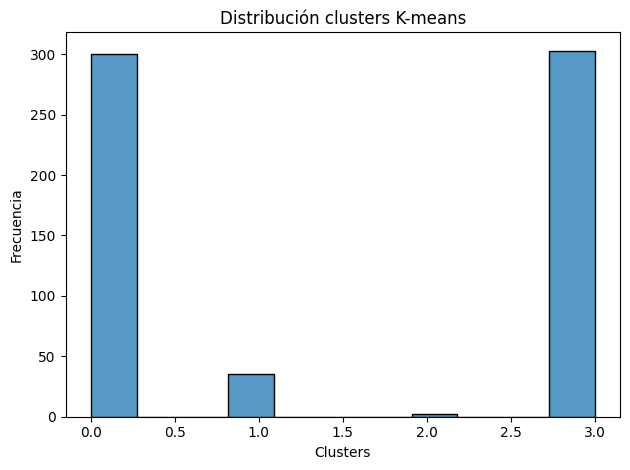

In [37]:
sns.histplot(data=data_train, x='cluster_knn')
plt.title('Distribución clusters K-means')
plt.xlabel(f'Clusters')
plt.ylabel(f'Frecuencia')

plt.tight_layout()
plt.savefig(f'./graphs/training/hist_res_knn.png')
plt.show()

### Entrenamiento con Autoencoder

In [ ]:
# 1. Simulación de tus datos (640 filas, 10 PCA)
# Reemplaza esto con: df = pd.read_csv('tu_archivo.csv')
# data = np.random.rand(640, 10) 

# Es vital escalar los datos para que las distancias en el AE sean uniformes
scaler = StandardScaler()
data_scaled_aec = scaler.fit_transform(data_pc10)
print(data_scaled_aec.shape)

# # 2. Configuración del Autoencoder
input_dim = 10  # Tus 10 componentes PCA
encoding_dim = 5 # Dimensión del espacio latente (puedes ajustarlo)

# Arquitectura
input_layer = Input(shape=(input_dim,))
# Encoder
encoded = Dense(8, activation='relu')(input_layer)
latent_space = Dense(encoding_dim, activation='relu')(encoded) # Capa clave
# Decoder
decoded = Dense(8, activation='relu')(latent_space)
output_layer = Dense(input_dim, activation='sigmoid')(decoded)

# Modelos
autoencoder = Model(input_layer, output_layer)
encoder = Model(input_layer, latent_space) # Para extraer características

autoencoder.compile(optimizer='adam', loss='mse')

# 3. Entrenamiento
autoencoder.fit(data_scaled_aec, data_scaled_aec, epochs=50, batch_size=32, shuffle=True, verbose=0)

# 4. Obtener las representaciones en el espacio latente
latent_representation = encoder.predict(data_scaled_aec)

# 5. Clustering (K-Means) para obtener centroides
# Supongamos que buscas 3 clusters de perfiles químicos
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(latent_representation)

# 6. Obtener los centroides
centroides_lat = kmeans.cluster_centers_

print(f"Forma de los centroides (Clusters, Dimensión Latente): {centroides_lat.shape}")
print("Centroides en el espacio latente:\n", centroides_lat)

(640, 10)
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Forma de los centroides (Clusters, Dimensión Latente): (4, 5)
Centroides en el espacio latente:
 [[2.292966   0.49836046 2.3832903  0.78478676 1.8609117 ]
 [2.9876952  0.3918906  2.8096209  0.19741839 5.217535  ]
 [3.757047   0.8221724  4.5384464  0.98477685 1.0138357 ]
 [8.35651    0.12625027 1.3426461  3.6331768  0.15372217]]


In [39]:
# 7. Definir el Decoder como un modelo independiente
# Tomamos las capas del autoencoder que van después del espacio latente
# (Ajusta los índices de las capas según cómo definiste tu modelo)
input_decoder = Input(shape=(encoding_dim,))
decoder_layer1 = autoencoder.layers[-2](input_decoder) # La capa de 8 neuronas
output_decoder = autoencoder.layers[-1](decoder_layer1) # La capa final de 10
decoder_model = Model(input_decoder, output_decoder)

# 8. "Pasar" los centroides por el Decoder
centroides_pca = decoder_model.predict(centroides_lat)

# 9. (Opcional) Revertir el escalado
# Si usaste StandardScaler al inicio, debes devolver los datos a su escala PCA original
centroides_ae = scaler.inverse_transform(centroides_pca)

print("Forma de los centroides en espacio PCA:", centroides_ae.shape)
print("Valores de los centroides (10 dimensiones):\n", centroides_ae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Forma de los centroides en espacio PCA: (4, 10)
Valores de los centroides (10 dimensiones):
 [[1.5254436e-01 3.3825386e-02 1.8375386e-01 3.5193708e-02 2.2579065e-02
  4.6127941e-02 1.2626925e-01 2.5600240e-02 3.5819300e-02 1.0863196e-01]
 [1.4223734e+00 5.0341850e-03 2.2477569e-01 1.5686588e-04 4.3732896e-02
  5.8909887e-03 4.9416733e-01 1.7893820e-03 3.0268034e-01 8.5274624e-03]
 [2.7011612e-03 4.9042348e-03 3.4761731e-02 3.9651178e-02 6.8017241e-04
  1.1976127e-02 8.7196110e-03 5.6995740e-03 4.4249356e-04 1.3771631e-01]
 [1.2686210e+00 1.6531004e-02 2.9956450e-04 1.0584532e+00 5.0912168e-02
  4.9711561e-01 4.0166888e-05 9.3335062e-01 3.2373745e-08 5.9224451e-03]]


### Entrenamiento modelo SOM (Kohonen)

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.06510367512306468
La primera muestra pertenece a la neurona: [1 7]


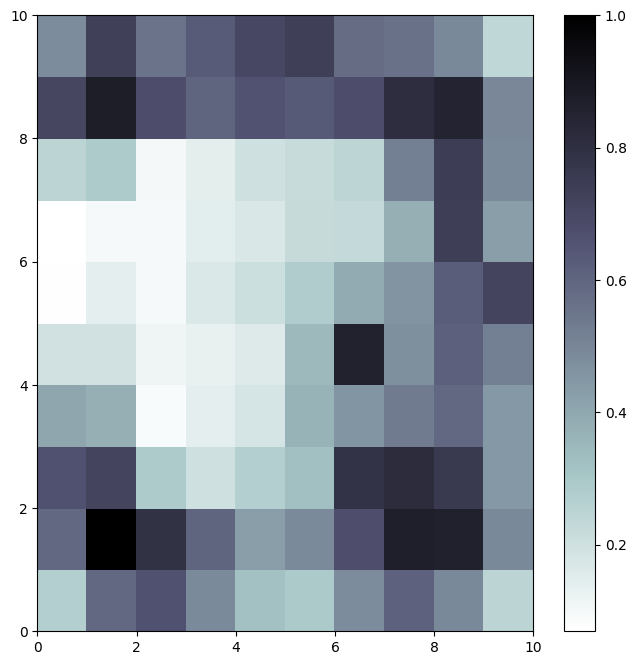

In [40]:
# 1. Simulación/Carga de tus 10 componentes PCA (640 filas)
# data = tu_dataframe_pca.values 
# data = np.random.rand(640, 10) 

# El SOM es sensible a la escala. Escalamos de 0 a 1.
scaler = MinMaxScaler()
data_scaled_som = scaler.fit_transform(data_pc10)

# 2. Configuración del SOM
# Para 640 muestras, una rejilla de 10x10 neuronas suele ser adecuada
som_grid_rows = 10
som_grid_cols = 10
input_len = data_scaled_som.shape[1] # Tus 10 componentes PCA

som = MiniSom(som_grid_rows, som_grid_cols, input_len, 
              sigma=1.0, learning_rate=0.5, random_seed=42)

# Inicialización de pesos y entrenamiento
som.pca_weights_init(data_scaled_som)
som.train_random(data_scaled_som, num_iteration=1000, verbose=True)

# 3. Visualización del "U-Matrix" (Mapa de Distancias)
# Los colores oscuros son grupos de datos, los claros son "fronteras"
plt.figure(figsize=(8, 8))
plt.pcolor(som.distance_map().T, cmap='bone_r') # Distancia entre neuronas
plt.colorbar()

# 4. Obtener a qué "neurona" (cluster) pertenece cada muestra
# Cada fila de tu base de datos se asigna a una coordenada (x, y)
clusters = np.array([som.winner(x) for x in data_scaled_som])

# Ejemplo: Ver la coordenada de la primera muestra de agua
print(f"La primera muestra pertenece a la neurona: {clusters[0]}")

# 5. Obtener los "Centroides"
# En un SOM, los pesos de cada neurona actúan como el centroide de ese grupo
pesos = som.get_weights() 
# pesos[x, y] te daría el perfil químico promedio de ese punto del mapa



In [41]:
# Obtenemos las coordenadas de la neurona ganadora para cada una de las 640 filas
ganadoras = [som.winner(x) for x in data_scaled_som]

# Contamos cuántas neuronas únicas fueron seleccionadas
centroides_activos = len(set(ganadoras))

print(f"El SOM tiene un total de {som_grid_rows * som_grid_cols} neuronas (posibles centroides).")
print(f"De ellas, {centroides_activos} centroides capturaron al menos una muestra de agua.")


El SOM tiene un total de 100 neuronas (posibles centroides).
De ellas, 62 centroides capturaron al menos una muestra de agua.


In [42]:
# 1. Aplanamos los pesos de la rejilla (de 10x10x10 a 100x10)
pesos_aplanados = pesos.reshape(-1, 10)

# 2. Agrupamos las neuronas en, por ejemplo, 3 clusters químicos
n_clusters = 4
km = KMeans(n_clusters=n_clusters, random_state=42)
km.fit(pesos_aplanados)

# 3. Estos son tus centroides finales en la dimensión del PCA (10)
centroides_som = km.cluster_centers_

print("Centroides finales (3 grupos, 10 variables PCA):")
print(centroides_som)

Centroides finales (3 grupos, 10 variables PCA):
[[ 0.13577543  0.14940382  0.47560554  0.57181823  0.43280149  0.11798686
   0.60154685  0.53072118  0.2999506   0.47953598]
 [ 0.81016353  0.14140673  0.42613264  0.54801785  0.44121653  0.11445262
   0.58798668  1.1214455   0.2748619   0.51517607]
 [-0.5902595   0.14956218  0.47560806  0.56408729  0.43607177  0.11131144
   0.60279607  1.32241439  0.30570767  0.48113836]
 [ 0.72320182  0.14843029  0.44499562  0.5913202   0.44924539  0.14463496
   0.57991464 -0.11561908  0.34213639  0.48762151]]


### Híbrido ABC + K-Means (Refinamiento)
En este modelo, el ABC se encarga de la exploración global y el K-Means de la explotación local.

1. Fase Global (ABC): Las abejas exploran el espacio de datos para encontrar regiones prometedoras donde podrían estar los clusters.

2. Fase Local (K-Means): Una vez que el ABC encuentra una solución cercana a la óptima, se utiliza el operador de K-Means para "pulir" esos centroides y ajustarlos rápidamente a los datos circundantes.

Resultado: Es mucho más rápido que el ABC puro y más preciso que el K-Means solo.


### El Flujo de Trabajo

La idea central es usar el ABC para inicializar de forma inteligente los centroides y luego dejar que K-Means termine el trabajo sucio de convergencia.

1. Inicialización (Abejas Exploradoras)En lugar de elegir puntos al azar, generas una población de "abejas". Cada abeja lleva consigo un vector que representa los centros de los $k$ clusters.

- Población: $N$ soluciones potenciales.
- Posición: Coordenadas de los centros de los grupos en el espacio de datos.2. Ciclo de 

2. Optimización Global (Fase ABC)Durante un número determinado de iteraciones, las abejas realizan tres tareas:
- Abejas Empleadas: Buscan nuevas soluciones cerca de las actuales (modifican un poco los centros) para ver si el error (SSE) disminuye.
- Abejas Observadoras: Eligen las mejores soluciones encontradas basándose en una probabilidad de "fitness". Entre mejor sea el clustering, más abejas irán a esa zona.
- Abejas Exploradoras: Si una solución no mejora después de varios intentos, la abeja la abandona y vuela a una zona totalmente nueva del dataset para evitar el estancamiento.

3. El "Salto" a K-Means (Refinamiento Local)Una vez que el algoritmo ABC ha convergido en una región prometedora (es decir, ya tenemos centros muy cercanos a los reales), tomamos la mejor abeja y usamos sus posiciones como el init de un algoritmo K-Means tradicional.

4. FinalizaciónK-Means realiza sus iteraciones finales (que suelen ser muy pocas en este punto) para asegurar que cada punto esté asignado al centroide más cercano de forma exacta.

```bash
# 1. Fase Global (Exploración con ABC)
for iteracion in rango(max_iter_abc):
    for abeja in poblacion:
        nueva_posicion = mover_abeja(abeja)
        evaluar_fitness(nueva_posicion) # Usando Suma de Errores Cuadráticos
    manejar_abejas_exploradoras() # Evita mínimos locales

# 2. Selección del Ganador
mejor_solucion = obtener_mejor_abeja(poblacion)

# 3. Fase Local (Refinamiento con K-Means)
# Usamos la mejor posición del ABC como semilla
kmeans_final = KMeans(n_clusters=k, init=mejor_solucion.centros)
kmeans_final.fit(datos)
```

In [43]:

def fitness_aptitude(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    # Penalización si se pierde un cluster
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    # Cálculo de SSE (Suma de errores cuadráticos)
    sse = 0
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    return sse

# 1.2. Índice de Davies-Bouldin (DBI)
def fitness_db_index(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    # El objetivo es MINIMIZAR este índice
    return davies_bouldin_score(data, labels)

# 1.3 Índice de Calinski-Harabasz (Varianza entre/dentro)
def fitness_calinski(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    score = calinski_harabasz_score(data, labels)
    # Como buscamos MINIMIZAR en tu config, retornamos el negativo
    return -score

# 1.4 Función de Fitness Combinada (Híbrida)
def fitness_hybrid(solution, data, n_clusters, n_features):
    centroids = solution.reshape((n_clusters, n_features))
    distances = cdist(data, centroids, 'euclidean')
    labels = np.argmin(distances, axis=1)
    
    if len(np.unique(labels)) < n_clusters:
        return 1e18
    
    # 1. Calcular SSE
    sse = 0
    for i in range(n_clusters):
        cluster_points = data[labels == i]
        sse += np.sum((cluster_points - centroids[i])**2)
    
    # 2. Calcular separación entre centroides (queremos que sea grande)
    # Calculamos la distancia promedio entre todos los pares de centros
    sep_distances = cdist(centroids, centroids, 'euclidean')
    # Sumamos solo la parte triangular superior para no repetir distancias ni usar la diagonal (0)
    separation = np.sum(np.triu(sep_distances, k=1))
    
    # Retornamos SSE penalizado por poca separación
    # (A menor separación, mayor el valor del fitness)
    return sse / (separation + 1e-6)


class MultiFitnessProblem(Problem):

    def __init__(self, lb, ub, minmax, data, n_clusters, n_features, fitness_logic, **kwargs):
        self.data = data
        self.n_clusters = n_clusters
        self.fitness_logic = fitness_logic
        self.n_features = n_features

        super().__init__(FloatVar(lb=lb, ub=ub), minmax)

    def obj_func(self, x):
        return self.fitness_logic(x, self.data, self.n_clusters, self.n_features)

In [44]:



def run_abck(data: pd.DataFrame, fitness_function: Callable, n_clusters_opt: int=4) -> Tuple[pd.DataFrame, ABC.OriginalABC, KMeans]:
    print(data)

    # 1. Configuración del Problema
    n_features = data.shape[1]
    low_bounds = np.min(data, axis=0).tolist() * n_clusters_opt
    up_bounds = np.max(data, axis=0).tolist() * n_clusters_opt

    abc_problem = MultiFitnessProblem (
        ub=up_bounds,
        lb=low_bounds,
        data=data,
        minmax="min",
        n_clusters=n_clusters_opt,
        n_features=n_features,
        fitness_logic= fitness_function
    )

    # 2. Ejecución de ABC
    model_abck = ABC.OriginalABC(epoch=100, pop_size=50)

    # 2.1. Obtenemos el objeto 'g_best' (Global Best Agent)
    g_best = model_abck.solve(abc_problem, seed=45)

    # 2.2. Captura de datos historicos de la solucion del modelo
    history_pos = np.array([agent.solution for agent in model_abck.history.list_global_best])

    # 2.3. Extraemos la posición y el fitness del objeto Agent
    best_pos = g_best.solution 
    best_fit = g_best.target.fitness

    print(f"Mejor Fitness (SSE) encontrado por ABC: {best_fit}")

    # 3. FASE HÍBRIDA: Refinamiento Local con K-Means
    # Usamos los centros encontrados por las abejas como semilla
    init_centroids = best_pos.reshape((n_clusters_opt, n_features))

    model_kmeans = KMeans(n_clusters=n_clusters_opt, init=init_centroids, n_init=1, max_iter=500)
    model_kmeans.fit(data)
    data['cluster_abck'] = model_kmeans.predict(data)

    print(f"Refinamiento K-Means completado. SSE Final: {model_kmeans.inertia_}")

    display(data.head())

    return data, model_abck, model_kmeans

In [45]:
n_clusters_opt = 4
X_data = data_train.drop(columns=['fecha', 'referencia', 'cluster_knn']).copy()
n_features = X_data.shape[1]

data_abck, model_abck, model_k = run_abck(X_data, fitness_calinski, n_clusters_opt)

path_nd = np.array([agent.solution for agent in model_abck.history.list_global_best])

2026/04/26 10:39:53 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(epoch=100, pop_size=50, n_limits=25)


          PC1       PC2       PC3       PC4        PC5        PC6       PC7  \
0   -2.173814  0.560687 -0.244653 -0.000022  -0.198642  -0.297102 -0.449977   
1   -2.135326  0.504553 -0.095536 -0.305302  -0.183530   0.056558 -0.207734   
2   -2.165984  0.458176 -0.002323 -0.326949  -0.166642   0.099856 -0.208867   
3   -2.211613  0.503966 -0.129927 -0.042172  -0.189566  -0.223255 -0.443616   
4   -2.324292  0.460397 -0.136303  0.202740  -0.166470  -0.296635 -0.488494   
..        ...       ...       ...       ...        ...        ...       ...   
635  1.285226 -0.218830 -0.664423 -0.236297   0.242890  -0.547417 -0.125620   
636  2.127979 -0.625815  1.358942  0.097421  -0.151548  -0.054191  0.606738   
637  0.143153  0.575170  0.865284 -0.296932   0.223312  -0.294826  0.112989   
638 -0.412851 -0.637269 -0.122417 -1.027177  -4.857845   4.332729 -2.052943   
639  1.049074  0.315701 -1.626347 -8.617998 -12.905628  13.121317 -4.097254   

          PC8       PC9      PC10  
0   -0.315806 -

2026/04/26 10:39:54 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -81.80364240751487, Global best: -81.80364240751487, Runtime: 0.11559 seconds
2026/04/26 10:39:54 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -81.80364240751487, Global best: -81.80364240751487, Runtime: 0.12040 seconds
2026/04/26 10:39:54 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.13401 seconds
2026/04/26 10:39:54 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.16304 seconds
2026/04/26 10:39:54 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -91.50294422088416, Global best: -91.50294422088416, Runtime: 0.17835 seconds
2026/04/26 10:39:54 PM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoc

Mejor Fitness (SSE) encontrado por ABC: -101.39681060516769
Refinamiento K-Means completado. SSE Final: 5555.456219957258


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_abck
0,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,3
1,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,3
2,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,3
3,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,3
4,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,3


In [46]:
print(type(path_nd))
matriz_reshaped = path_nd.reshape((100, n_clusters_opt, n_features))
print(matriz_reshaped.shape)
# print(matriz_reshaped)

<class 'numpy.ndarray'>
(100, 4, 10)


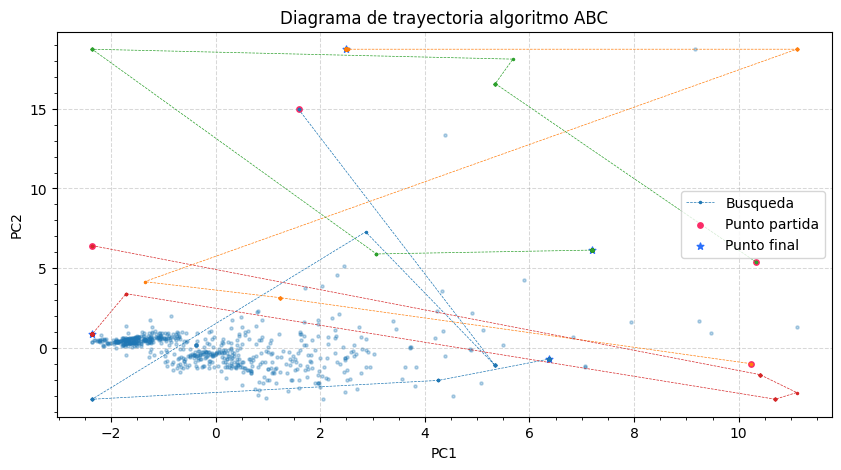

In [47]:
# indices de columas de PC
col_i_x = 0
col_i_y = 1

fig_003, ax_003 = plt.subplots(figsize=(10,5))

for c_i in range(n_clusters_opt):
    ax_003.plot(matriz_reshaped[:,c_i,:][:,col_i_x], matriz_reshaped[:,c_i,:][:,col_i_y], '.--', linewidth=0.5, markersize=3)
    ax_003.scatter(matriz_reshaped[:,c_i,:][0,col_i_x], matriz_reshaped[:,c_i,:][0,col_i_y], marker='o', s=15, color="#fb2b67")
    ax_003.scatter(matriz_reshaped[:,c_i,:][-1,col_i_x],matriz_reshaped[:,c_i,:][-1,col_i_y], marker='*', s=25, color="#2b6ffb")

ax_003.scatter(data["PC1"], data["PC2"], s=5, alpha=0.30)
    
ax_003.grid(color="gray", alpha=0.30, linewidth=0.75, linestyle='dashed')
ax_003.set_xlabel("PC1")
ax_003.set_ylabel("PC2")
ax_003.minorticks_on()
ax_003.legend([f"Busqueda", "Punto partida", "Punto final"])
ax_003.set_title("Diagrama de trayectoria algoritmo ABC")
plt.show()

In [48]:
out_path ='./graphs/training/res_abck_class_'

graph_dist_clusters(data_abck, column_names_knn, pca_n_cols, pca_n_rows, 'cluster_abck', out_path)

This directory graphs/training is not empty. Choose another one.


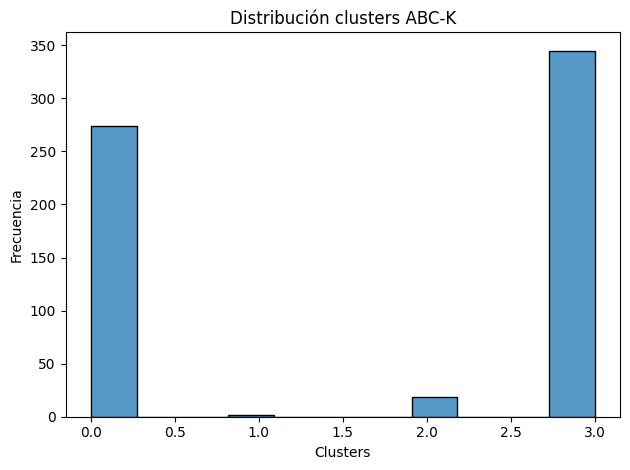

In [49]:
sns.histplot(data=data_abck, x='cluster_abck')
plt.title('Distribución clusters ABC-K')
plt.xlabel(f'Clusters')
plt.ylabel(f'Frecuencia')

plt.tight_layout()
plt.savefig(f'./graphs/training/hist_res_abck.png')
plt.show()

In [50]:
display(data_abck.head())
data_abck.to_csv("../data/results/pca_data_abck.csv", index=False, sep=',', encoding='utf-8')

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,cluster_abck
0,-2.173814,0.560687,-0.244653,-0.000022,-0.198642,-0.297102,-0.449977,-0.315806,-0.283185,-0.048349,3
1,-2.135326,0.504553,-0.095536,-0.305302,-0.183530,0.056558,-0.207734,-0.030956,0.008387,-0.057170,3
2,-2.165984,0.458176,-0.002323,-0.326949,-0.166642,0.099856,-0.208867,0.031741,0.089761,0.017689,3
3,-2.211613,0.503966,-0.129927,-0.042172,-0.189566,-0.223255,-0.443616,-0.230362,-0.179810,0.050264,3
4,-2.324292,0.460397,-0.136303,0.202740,-0.166470,-0.296635,-0.488494,-0.353747,-0.337112,0.184335,3


### Convirtiendo modelo a binario

In [55]:
centroides_abck = model_k.cluster_centers_
joblib.dump(centroides_abck, '../binary/cluster_centers.joblib')

['../binary/cluster_centers.joblib']

### Comparación entre métodos

In [57]:
print(centroides_knn.shape)
print(centroides_abck.shape)
print(centroides_ae.shape)
print(centroides_som.shape)


(4, 5)
(4, 10)
(4, 10)
(4, 10)


In [56]:
# 1. Diccionario con tus centroides (Carga aquí tus resultados de 10 dimensiones)
# Cada valor debe ser un array de (n_clusters, 10)
mis_centroides = {
    "K-Means": centroides_knn,
    "ABC + K-Means": centroides_abck,
    "Autoencoder + K-Means": centroides_ae,
    "SOM + K-Means": centroides_som
}

def calcular_metricas_desde_centroides(X, centroides_dict):
    resumen = []
    
    for nombre, centros in centroides_dict.items():
        # ASIGNACIÓN: Cada punto al centroide más cercano (Distancia Euclidiana)
        distancias = cdist(X, centros, metric='euclidean')
        etiquetas = np.argmin(distancias, axis=1)
        
        # CÁLCULO DE MÉTRICAS
        # Silueta: Evalúa cohesión vs separación
        sil = silhouette_score(X, etiquetas)
        
        # Calinski-Harabasz: Mayor valor = mejor definición
        ch = calinski_harabasz_score(X, etiquetas)
        
        # Davies-Bouldin: Menor valor = clusters menos solapados
        db = davies_bouldin_score(X, etiquetas)
        
        resumen.append({
            'Método': nombre,
            'Silhouette (↑)': round(sil, 4),
            'Calinski-H (↑)': round(ch, 2),
            'Davies-Bouldin (↓)': round(db, 4)
        })
        
    return pd.DataFrame(resumen)

# 3. Ejecución
df_comparativo = calcular_metricas_desde_centroides(data_pc10, mis_centroides)

# 4. Mostrar y ordenar por el mejor Silhouette
print(df_comparativo.sort_values(by='Silhouette (↑)', ascending=False))

ValueError: XA and XB must have the same number of columns (i.e. feature dimension.)